# 🗺️ Kenya Weather Forecast — Interactive Map
**Uses the best trained model (GRU) to predict 7-day weather for all 47 counties**

What this notebook produces:
- Interactive Kenya map with all 47 county markers
- Click any county → see 7-day forecast for all 5 weather variables
- Color-coded markers by temperature zone
- Exportable as a standalone HTML file

## ⚙️ Install & Import

In [1]:
!pip install folium tensorflow scikit-learn joblib pandas numpy -q

import numpy as np
import pandas as pd
import folium
import joblib, json, os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from google.colab import drive
drive.mount('/content/drive')

print('✅ Libraries loaded')

Mounted at /content/drive
✅ Libraries loaded


## 📂 Load Model, Scalers & Data

In [3]:
MODEL_DIR = '/content/drive/MyDrive/kenya_models'
DATA_PATH = '/content/drive/MyDrive/kenya_weather_data/kenya_all_counties.csv'

# Load metadata
with open(f'{MODEL_DIR}/model_metadata.json') as f:
    meta = json.load(f)

BEST_MODEL    = meta['best_model']       # GRU
LOOKBACK      = meta['lookback']         # 30
FORECAST_DAYS = meta['forecast_days']    # 7
TARGET_COLS   = meta['target_cols']
FEATURE_COLS  = meta['feature_cols']

# Load best model
model = keras.models.load_model(f'{MODEL_DIR}/best_model_{BEST_MODEL}.h5', custom_objects={'mse': tf.keras.losses.MeanSquaredError()})

# Load scalers
scaler_dict = joblib.load(f'{MODEL_DIR}/scalers.pkl')

# Load data
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['county', 'date']).reset_index(drop=True)

print(f'✅ Model loaded  : {BEST_MODEL}')
print(f'   Lookback      : {LOOKBACK} days')
print(f'   Forecast      : {FORECAST_DAYS} days')
print(f'   Counties      : {df["county"].nunique()}')
print(f'   Targets       : {TARGET_COLS}')

✅ Model loaded  : GRU
   Lookback      : 30 days
   Forecast      : 7 days
   Counties      : 47
   Targets       : ['temp_mean_c', 'rainfall_mm', 'humidity_pct', 'windspeed_kmh', 'pressure_hpa']


## 🛠️ Rebuild Features & Predict All Counties

In [9]:
def engineer_features(cdf):
    """Apply same feature engineering as training."""
    cdf = cdf.copy()
    TARGET_COLS_LOCAL = ['temp_mean_c','rainfall_mm','humidity_pct','windspeed_kmh','pressure_hpa']

    # Handle missing
    for col in TARGET_COLS_LOCAL:
        if col in cdf.columns:
            cdf[col] = cdf[col].interpolate().fillna(method='bfill').fillna(method='ffill')

    # Time features
    cdf['day_of_year'] = cdf['date'].dt.dayofyear
    cdf['month']       = cdf['date'].dt.month
    cdf['week']        = cdf['date'].dt.isocalendar().week.astype(int)
    cdf['sin_doy']     = np.sin(2 * np.pi * cdf['day_of_year'] / 365)
    cdf['cos_doy']     = np.cos(2 * np.pi * cdf['day_of_year'] / 365)
    cdf['sin_month']   = np.sin(2 * np.pi * cdf['month'] / 12)
    cdf['cos_month']   = np.cos(2 * np.pi * cdf['month'] / 12)

    # Lag & rolling features
    for col in TARGET_COLS_LOCAL:
        if col in cdf.columns:
            for lag in [1, 3, 7]:
                cdf[f'{col}_lag{lag}'] = cdf[col].shift(lag)
            for win in [7, 14]:
                cdf[f'{col}_roll{win}mean'] = cdf[col].rolling(win, min_periods=1).mean()

    cdf.dropna(inplace=True)
    return cdf


def predict_county(county_name):
    """Predict next 7 days for a county using the last 30 days of data."""
    cdf     = df[df['county'] == county_name].copy().reset_index(drop=True)
    cdf_feat = engineer_features(cdf)

    # Use only columns the model was trained on
    available = [c for c in FEATURE_COLS if c in cdf_feat.columns]
    missing_c = [c for c in FEATURE_COLS if c not in cdf_feat.columns]
    for c in missing_c:
        cdf_feat[c] = 0.0   # fill any missing feature with 0

    scaler  = scaler_dict[county_name]
    scaled  = scaler.transform(cdf_feat[FEATURE_COLS])

    # Take the last LOOKBACK days as input
    X_input = scaled[-LOOKBACK:].reshape(1, LOOKBACK, len(FEATURE_COLS))

    # Predict (normalized)
    pred_norm = model.predict(X_input, verbose=0)[0]   # (7, 5)

    # Inverse transform — only for target columns
    target_idx = [FEATURE_COLS.index(t) for t in TARGET_COLS]
    dummy      = np.zeros((FORECAST_DAYS, len(FEATURE_COLS)))
    dummy[:, target_idx] = pred_norm
    inv        = scaler.inverse_transform(dummy)
    pred_real  = inv[:, target_idx]   # (7, 5) — real-world values

    # Build forecast dataframe
    last_date  = cdf['date'].max()
    dates      = pd.date_range(last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)
    forecast   = pd.DataFrame(pred_real, columns=TARGET_COLS)
    forecast.insert(0, 'date', dates)
    forecast.insert(1, 'county', county_name)

    # Clip to realistic ranges
    forecast['temp_mean_c']   = forecast['temp_mean_c'].clip(5, 45)
    forecast['rainfall_mm']   = forecast['rainfall_mm'].clip(0, 200)
    forecast['humidity_pct']  = forecast['humidity_pct'].clip(0, 100)
    forecast['windspeed_kmh'] = forecast['windspeed_kmh'].clip(0, 120)
    forecast['pressure_hpa']  = forecast['pressure_hpa'].clip(850, 1050)

    return forecast


# Generate predictions for ALL 47 counties
print('🔮 Generating 7-day forecasts for all 47 counties...')
all_forecasts = {}
county_coords = df.groupby('county')[['latitude','longitude']].first().to_dict('index')

for county in df['county'].unique():
    try:
        all_forecasts[county] = predict_county(county)
    except Exception as e:
        print(f'  ⚠️ {county}: {e}')

print(f'✅ Forecasts generated for {len(all_forecasts)}/47 counties')
print('\nSample forecast — Nairobi:')
print(all_forecasts['Nairobi'].round(2).to_string(index=False))

🔮 Generating 7-day forecasts for all 47 counties...
✅ Forecasts generated for 47/47 counties

Sample forecast — Nairobi:
      date  county  temp_mean_c  rainfall_mm  humidity_pct  windspeed_kmh  pressure_hpa
2026-02-28 Nairobi        20.86         1.60         63.42          15.37         850.0
2026-03-01 Nairobi        20.43         3.07         68.06          14.60         850.0
2026-03-02 Nairobi        20.00         4.09         72.03          13.95         850.0
2026-03-03 Nairobi        19.78         4.07         73.34          13.58         850.0
2026-03-04 Nairobi        19.85         3.19         71.71          13.68         850.0
2026-03-05 Nairobi        20.04         1.88         68.91          14.07         850.0
2026-03-06 Nairobi        20.19         1.29         66.87          14.50         850.0


## 🗺️ Build Interactive Kenya Map

In [10]:
def temp_to_color(temp):
    """Color markers by temperature."""
    if temp < 15:   return 'blue'
    elif temp < 20: return 'lightblue'
    elif temp < 25: return 'green'
    elif temp < 30: return 'orange'
    else:           return 'red'

def rain_emoji(mm):
    if mm < 1:   return '☀️'
    elif mm < 5: return '🌤️'
    elif mm < 15: return '🌧️'
    else:        return '⛈️'

def build_popup(county, forecast):
    """Build a rich HTML popup for each county marker."""
    rows = ''
    for _, row in forecast.iterrows():
        day   = row['date'].strftime('%a %d %b')
        emoji = rain_emoji(row['rainfall_mm'])
        rows += f"""
        <tr>
          <td><b>{day}</b></td>
          <td>{emoji} {row['temp_mean_c']:.1f}°C</td>
          <td>💧 {row['rainfall_mm']:.1f}mm</td>
          <td>💦 {row['humidity_pct']:.0f}%</td>
          <td>💨 {row['windspeed_kmh']:.1f}km/h</td>
          <td>🔵 {row['pressure_hpa']:.0f}hPa</td>
        </tr>"""

    avg_temp = forecast['temp_mean_c'].mean()
    avg_rain = forecast['rainfall_mm'].sum()

    html = f"""
    <div style="font-family: Arial, sans-serif; width: 480px;">
      <div style="background: linear-gradient(135deg, #1a6b3c, #2ecc71);
                  color: white; padding: 10px 14px; border-radius: 6px 6px 0 0;">
        <h3 style="margin:0; font-size:16px;">📍 {county} County</h3>
        <p style="margin:2px 0 0; font-size:12px; opacity:0.9;">
          7-Day Forecast | Avg: {avg_temp:.1f}°C | Total Rain: {avg_rain:.1f}mm
        </p>
      </div>
      <table style="width:100%; border-collapse:collapse; font-size:12px;">
        <thead>
          <tr style="background:#f0f0f0;">
            <th style="padding:5px; text-align:left;">Day</th>
            <th>Temp</th><th>Rain</th><th>Humidity</th>
            <th>Wind</th><th>Pressure</th>
          </tr>
        </thead>
        <tbody>{rows}</tbody>
      </table>
      <p style="font-size:10px; color:#888; margin:5px; text-align:right;">
        Powered by GRU Deep Learning Model · Victor Cheruiyot, MUST
      </p>
    </div>"""
    return html


# ── Create the map ────────────────────────────────────────────────────────────
kenya_map = folium.Map(
    location=[0.0236, 37.9062],   # centre of Kenya
    zoom_start=6,
    tiles='CartoDB positron'
)

# Add title
title_html = '''
<div style="position: fixed; top: 15px; left: 50%; transform: translateX(-50%);
            z-index: 1000; background: white; padding: 10px 20px;
            border-radius: 8px; box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            font-family: Arial; text-align: center;">
  <b style="font-size:16px; color:#1a6b3c;">🌦️ Kenya County Weather Forecast</b><br>
  <span style="font-size:11px; color:#666;">GRU Deep Learning Model · 7-Day Predictions · Click any marker</span>
</div>'''
kenya_map.get_root().html.add_child(folium.Element(title_html))

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 30px; right: 15px; z-index: 1000;
            background: white; padding: 10px 14px; border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.2); font-family: Arial; font-size:12px;">
  <b>Temperature (°C)</b><br>
  <span style="color:blue;">●</span> &lt; 15°C (Cool)<br>
  <span style="color:lightblue;">●</span> 15–20°C<br>
  <span style="color:green;">●</span> 20–25°C<br>
  <span style="color:orange;">●</span> 25–30°C<br>
  <span style="color:red;">●</span> &gt; 30°C (Hot)
</div>'''
kenya_map.get_root().html.add_child(folium.Element(legend_html))

# Add county markers
for county, forecast in all_forecasts.items():
    coords   = county_coords.get(county, {})
    lat      = coords.get('latitude', 0)
    lon      = coords.get('longitude', 0)
    avg_temp = forecast['temp_mean_c'].mean()
    color    = temp_to_color(avg_temp)
    popup_html = build_popup(county, forecast)

    folium.CircleMarker(
        location=[lat, lon],
        radius=12,
        color='white',
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        tooltip=folium.Tooltip(
            f"<b>{county}</b><br>{avg_temp:.1f}°C avg · Click for 7-day forecast",
            sticky=True
        ),
        popup=folium.Popup(folium.IFrame(popup_html, width=500, height=230), max_width=510)
    ).add_to(kenya_map)

    # County name label
    folium.Marker(
        location=[lat, lon],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px; color:#333; font-weight:bold; \
                   white-space:nowrap; margin-top:14px; margin-left:5px;">{county}</div>',
            icon_size=(80, 20),
            icon_anchor=(0, 0)
        )
    ).add_to(kenya_map)

print(f'✅ Map built with {len(all_forecasts)} county markers')
print('   Hover over a marker to see county name and avg temp')
print('   Click a marker to see full 7-day forecast')

✅ Map built with 47 county markers
   Hover over a marker to see county name and avg temp
   Click a marker to see full 7-day forecast


## 💾 Save & Display Map

In [11]:
# Save map to Google Drive
map_path = f'{MODEL_DIR}/kenya_weather_map.html'
kenya_map.save(map_path)
print(f'✅ Map saved to: {map_path}')
print('   Open this HTML file in any browser to use the interactive map!')

# Also save all forecasts as CSV
forecasts_combined = pd.concat(all_forecasts.values(), ignore_index=True)
forecasts_combined.to_csv(f'{MODEL_DIR}/all_county_forecasts.csv', index=False)
print(f'✅ Forecasts saved as CSV too')

# Display in Colab
kenya_map

✅ Map saved to: /content/drive/MyDrive/kenya_models/kenya_weather_map.html
   Open this HTML file in any browser to use the interactive map!
✅ Forecasts saved as CSV too


## 📊 Cell 6 — Bonus: County Forecast Summary Table

🌡️  KENYA 7-DAY FORECAST SUMMARY (sorted by temperature)
         County  Avg Temp (°C)  Total Rain (mm)  Avg Humidity (%)  Avg Wind (km/h)  Avg Pressure
     Tana River           30.4              1.1              53.0             21.9        1000.2
          Wajir           30.4              1.1              42.1             20.5         982.2
        Garissa           30.3              2.8              48.7             19.5         993.7
        Turkana           30.0              0.3              28.8             19.6         955.3
        Mandera           29.8              0.4              29.7             19.5         987.4
           Lamu           28.2              6.0              70.9             22.3        1009.5
         Kilifi           28.1              5.7              72.9             20.1        1010.8
        Mombasa           27.8             11.7              79.6             19.6        1008.8
        Baringo           27.0              1.3              37.0     

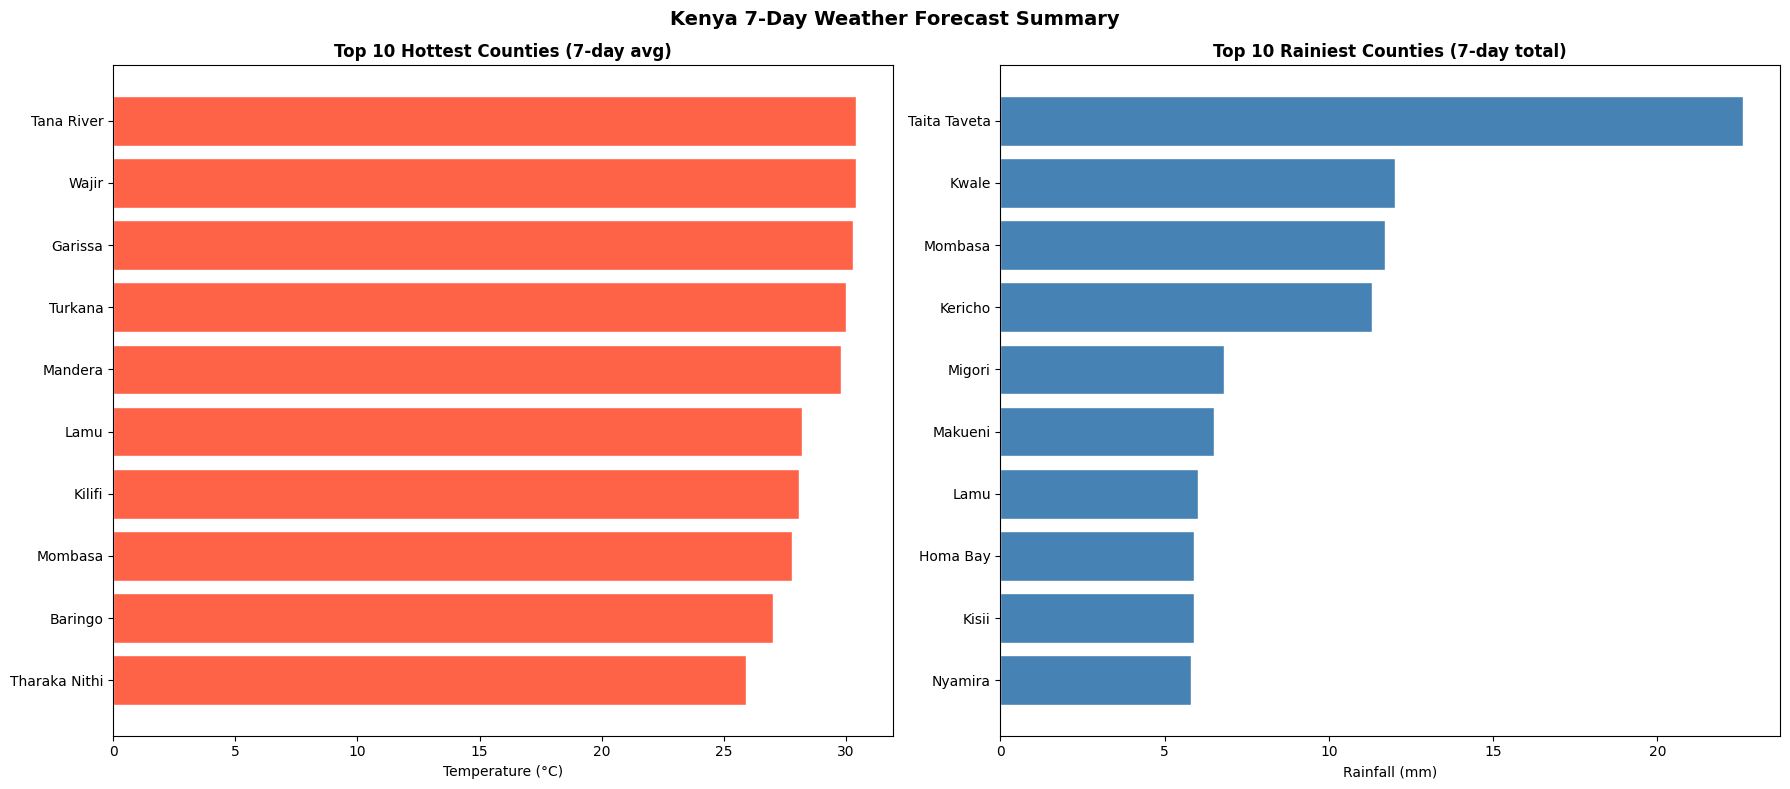

✅ Summary chart saved!


In [7]:
import matplotlib.pyplot as plt

# Summary table — one row per county, 7-day averages
summary_rows = []
for county, fc in all_forecasts.items():
    summary_rows.append({
        'County'         : county,
        'Avg Temp (°C)'  : round(fc['temp_mean_c'].mean(), 1),
        'Total Rain (mm)': round(fc['rainfall_mm'].sum(), 1),
        'Avg Humidity (%)': round(fc['humidity_pct'].mean(), 1),
        'Avg Wind (km/h)': round(fc['windspeed_kmh'].mean(), 1),
        'Avg Pressure'   : round(fc['pressure_hpa'].mean(), 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Avg Temp (°C)', ascending=False)

print('🌡️  KENYA 7-DAY FORECAST SUMMARY (sorted by temperature)')
print('=' * 75)
print(summary_df.to_string(index=False))

# Bar chart — temperature by county
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top_hot  = summary_df.head(10)
top_rain = summary_df.sort_values('Total Rain (mm)', ascending=False).head(10)

axes[0].barh(top_hot['County'], top_hot['Avg Temp (°C)'],
             color='tomato', edgecolor='white')
axes[0].set_title('Top 10 Hottest Counties (7-day avg)', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].invert_yaxis()

axes[1].barh(top_rain['County'], top_rain['Total Rain (mm)'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Rainiest Counties (7-day total)', fontweight='bold')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].invert_yaxis()

plt.suptitle('Kenya 7-Day Weather Forecast Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/forecast_summary.png', dpi=150)
plt.show()
print('✅ Summary chart saved!')

---
## ✅ You're done!

Files saved to `/content/drive/MyDrive/kenya_models/`:
- `kenya_weather_map.html` — open in any browser, interactive map with all 47 counties
- `all_county_forecasts.csv` — all 7-day predictions in a table
- `forecast_summary.png` — bar charts for temp and rainfall

**To share your map:** Download `kenya_weather_map.html` from Drive and open it in Chrome/Firefox — no internet needed, it's fully self-contained!